## 1. Combine all data

First: run all independent notebooks before starting on this overall notebook!

### Load categoric dataframe

We use NL columns

Mind you : certain joints are missing:
- Swelling of the HIP is missing in Dutch, Swedish & Finnish data
- acromioclavicular is missing from Danmark
- cervical spine is missing from Swedish & Finnish data


In [1]:
import pandas as pd
df_categoric_nor = pd.read_csv('Norway/df_norway_categoric_ohe.csv', sep='|')
df_categoric_swefi =pd.read_csv('Sweden_Finland/df_swefi_categoric_ohe.csv', sep='|')
df_categoric_nl =pd.read_csv('Netherlands/df_netherlands_categoric_ohe.csv', sep='|')
df_categoric_dan =pd.read_csv('Danmarsk/df_danmark_categoric_ohe.csv', sep='|')

l_cat = set(df_categoric_nl.columns) - set(['Pijn_acromioclaviaculair L_negative', 'Pijn_acromioclaviaculair L_positive', 'Zwelling_acromioclaviaculair L_negative', 'Zwelling_acromioclaviaculair L_positive', 'Pijn_acromioclaviaculair R_negative', 'Pijn_acromioclaviaculair R_positive', 'Zwelling_acromioclaviaculair R_negative', 'Zwelling_acromioclaviaculair R_positive']) #[1:] # skip patient id
l_cat = list(l_cat)
l_cat.remove("PATNR")
l_cat.append("PATNR")
df_categoric_replication = pd.concat([df_categoric_nor[l_cat], df_categoric_swefi[l_cat]])
df_categoric_replication = pd.concat([df_categoric_replication[l_cat], df_categoric_nl[l_cat]])
df_categoric_replication = pd.concat([df_categoric_replication[l_cat], df_categoric_dan[l_cat]])
df_categoric_replication = df_categoric_replication.reset_index(drop=True)

## #2. Project new data

Load different custom env: 
conda activate /exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/

### #2.1 Force same dimensions
We have less caterogical features in the replication set, thus we are required to reduce the dimensions. In order to create a shared latent space in the next step

In [3]:
import pandas as pd

df_numeric_nor = pd.read_csv('Norway/Norway_Lab_wide_scaled.csv', sep='|')
df_numeric_swefi =pd.read_csv('Sweden_Finland/SweFi_Lab_wide_scaled.csv', sep='|')
df_numeric_nl =pd.read_csv('Netherlands/Netherlands_Lab_wide_scaled.csv', sep='|')
df_numeric_dan =pd.read_csv('Danmark/Danmark_Lab_wide_scaled.csv', sep='|')

df_numeric_replication = pd.concat([df_numeric_nor, df_numeric_swefi])
df_numeric_replication = pd.concat([df_numeric_replication, df_numeric_nl])
df_numeric_replication = pd.concat([df_numeric_replication, df_numeric_dan])

In [30]:
import pandas as pd

df_numeric_nor_un = pd.read_csv('Norway/Norway_Lab_wide_unscaled.csv', sep='|')
df_numeric_swefi_un =pd.read_csv('Sweden_Finland/SweFi_Lab_wide_unscaled.csv', sep='|')
df_numeric_nl_un =pd.read_csv('Netherlands/Netherlands_Lab_wide_unscaled.csv', sep='|')
df_numeric_dan_un =pd.read_csv('Danmark/Danmark_Lab_wide_unscaled.csv', sep='|')

df_numeric_replication_un = pd.concat([df_numeric_nor_un, df_numeric_swefi_un])
df_numeric_replication_un = pd.concat([df_numeric_replication_un, df_numeric_nl_un])
df_numeric_replication_un = pd.concat([df_numeric_replication_un, df_numeric_dan_un])

In [23]:
print('Patients: ', len(df_numeric_replication['PATNR'].unique()))
df_numeric_replication = df_numeric_replication.dropna()
print('Patients without ESR (or CRP) info: ', len(df_numeric_replication['PATNR'].unique()))
df_numeric_replication = df_numeric_replication.reset_index(drop=True)
df_categoric_replication = df_categoric_replication[df_categoric_replication['PATNR'].isin(df_numeric_replication['PATNR'].unique())].reset_index(drop=True)
df_numeric_replication_un = df_numeric_replication_un[df_numeric_replication_un['PATNR'].isin(df_numeric_replication_un['PATNR'].unique())].reset_index(drop=True)

Patients:  810
Patients without ESR (or CRP) info:  806


In [330]:
# Variables from replication set
df_categoric_replication.to_csv('Total/df_Nordstar_categoric_ohe.csv', sep='|', index=False)#[l_cat]
df_numeric_replication.to_csv('Total/Nordstar_Lab_wide_scaled.csv', sep='|', index=False)#[l_num]
df_numeric_replication_un.to_csv('Total/Nordstar_Lab_wide_unscaled.csv', sep='|', index=False)#[l_num]

## #2. Project new data

Load different custom env: 
conda activate /exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/

### #2.1 Force same dimensions
We have less caterogical features in the replication set, thus we are required to reduce the dimensions. In order to create a shared latent space in the next step

In [ ]:
import pandas as pd

l_num = ['BSE', 'Age'] # 'Ht', 
#l_num = ['Leuko', 'Ht', 'Hb', 'MCV', 'Trom', 'BSE', 'Age', 'PATNR']

# Variables from development set
df_numeric = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_lab_scaled_demographics.csv', sep=',')
df_numeric['PATNR'] = df_numeric['pseudoId']
df_numeric = df_numeric[l_num].copy()
df_categoric= pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_categoric_wAge.csv', sep=',')
df_categoric['PATNR'] = df_categoric['pseudoId']
df_categoric = df_categoric[l_cat].copy()
l_num.append('PATNR')

# Variables from replication set
df_categoric_replication = pd.read_csv('Total/df_Nordstar_categoric_ohe.csv', sep='|')[l_cat]
df_numeric_replication = pd.read_csv('Total/Nordstar_Lab_wide_scaled.csv', sep='|')[l_num]


# Select complete patients
l_essential = ['RF', 'aCCP', 'PATNR'] #  'Ht',
l_pat_repl = list(df_categoric_replication[l_essential].dropna()['PATNR'].unique())

df_categoric_replication = df_categoric_replication[df_categoric_replication['PATNR'].isin(l_pat_repl)].reset_index(drop=True)
df_numeric_replication = df_numeric_replication[df_numeric_replication['PATNR'].isin(l_pat_repl)].reset_index(drop=True)

df_categoric_replication = df_categoric_replication.fillna(0)
df_numeric_replication = df_numeric_replication.fillna(0)

### Create metadata

In [ ]:
df_numeric_raw = pd.read_csv('Total/Nordstar_Lab_wide_unscaled.csv', sep='|')[l_num]

df_meta_new = pd.merge(df_categoric_replication, df_numeric_raw, left_on='PATNR', right_on='PATNR')
df_meta_new['pseudoId'] = df_meta_new['PATNR'] 

### create combined metadata

In [333]:
# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0
metadata_RA['PATNR'] = metadata_RA['pseudoId'].str[:-2] 

df_meta_new['Replication'] = 1
df_meta_new['pseudoId'] = df_meta_new['PATNR'].copy()

df_meta_full = pd.concat([df_meta_new, metadata_RA])
df_meta_full.reset_index(drop=True)
df_meta_full.to_csv('Total/Metadata_complete_Nordstar.csv', sep='|', index=False)

### #2.2 learn shared product space

In [334]:
import os, platform, subprocess, re

def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

get_processor_name()

' Intel(R) Xeon(R) CPU E5-2690 v3 @ 2.60GHz'

In [335]:
import time
import numpy as np
from mmae.multimodal_autoencoder import MultimodalAutoencoder # MMAE
import tensorflow as tf


# Be aware: Remove features with zero variation!!
input_shapes = {'Categoric': df_categoric[l_cat[:-1]].shape[1:], 'Numeric': df_numeric.shape[1:]} 
data = [np.array(df_categoric[l_cat[:-1]].values), np.array(df_numeric.values)]

# Number of units of each layer of encoder network
hidden_dims = [128, 64, 8] # 16?
# Output activation functions for each modality
output_activations = ['sigmoid' , 'relu'] # , 'relu'
# Name of Keras optimizer
optimizer = 'adam'
# Loss functions corresponding to a noise model for each modality
loss = ['bernoulli_divergence', 'gaussian_divergence']

# Set seed
tf.random.set_seed(20240609) #20240617

# Construct autoencoder network
autoencoder = MultimodalAutoencoder(input_shapes, hidden_dims,
                                    output_activations)
autoencoder.compile(optimizer, loss)


t0 = time.time()
# Train model where input and output are the same # 
history = autoencoder.fit(data, epochs=100, validation_split=0.2)

t1 = time.time()
print('Time to create product space: ' + str(t1-t0))


# Get Latent space of original data
z_filtered = autoencoder.encode(data)
 
#tf.keras.models.save_model()
# Save maui model state (that only uses variables also present in replication set)
#maui_model.save('/exports/reum/tdmaarseveen/RA_Clustering/models/replication_maui')
autoencoder.save('models/NORDSTAR_MMAE')

# Save shared productspace (that only uses variables also present in replication set)
l_embedding = ['PATNR']

df_z = pd.DataFrame(z_filtered)
for ix, col in enumerate(df_z): # z-filtered might be row based
    df_z['LF%s' % ix] = df_z[ix].copy()
    l_embedding.append('LF%s' % ix)
 
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0)
df_z.insert(0, 'PATNR', metadata_RA['pseudoId'])
df_z = df_z[l_embedding].copy()
   
df_z[l_embedding].to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/NORDSTAR_embedding_Total.csv', index=False, sep=',')


i,dim: 0 128
i,dim: 1 64
i,dim: 2 8
Names MM: Tensor("concatenate_5/Identity:0", shape=(None, 265), dtype=float32)
L33: {'batch_input_shape': (None, 8), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'representation'}
L33: {'name': 'decoding_5', 'trainable': True, 'dtype': 'float32', 'node_def': {'name': 'decoding_5', 'op': 'Identity', 'input': ['representation_10'], 'attr': {'T': {'type': 'DT_FLOAT'}}}, 'constants': {}}
L33: {'name': 'dense3_1', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'class_name': 'GlorotUniform', 'config': {'seed': None}}, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}
L33: {'name': 'kernel2_2', 'trainable': True, 'dtype': 'float32', 'rate': 0.0, 'noise_shape': None, 'seed': None}
L33: {'name': 'dense3_0', 'trainable': True, 'dtype'

35/35 [==============================] - 0s 3ms/step - loss: 0.5790 - Categoric_reconstruction_loss: 0.1893 - Numeric_reconstruction_loss: 0.3896 - val_loss: 0.5381 - val_Categoric_reconstruction_loss: 0.2000 - val_Numeric_reconstruction_loss: 0.3380
Epoch 54/100
35/35 [==============================] - 0s 3ms/step - loss: 0.5777 - Categoric_reconstruction_loss: 0.1882 - Numeric_reconstruction_loss: 0.3895 - val_loss: 0.5379 - val_Categoric_reconstruction_loss: 0.1998 - val_Numeric_reconstruction_loss: 0.3381
Epoch 55/100
35/35 [==============================] - 0s 3ms/step - loss: 0.5777 - Categoric_reconstruction_loss: 0.1875 - Numeric_reconstruction_loss: 0.3902 - val_loss: 0.5376 - val_Categoric_reconstruction_loss: 0.1993 - val_Numeric_reconstruction_loss: 0.3384
Epoch 56/100
35/35 [==============================] - 0s 3ms/step - loss: 0.5762 - Categoric_reconstruction_loss: 0.1862 - Numeric_reconstruction_loss: 0.3901 - val_loss: 0.5367 - val_Categoric_reconstruction_loss: 0.1990

### #2.2 Project novel instances onto latent embedding


In [ ]:
import pandas as pd


df_imp= pd.read_csv('Total/Metadata_complete_Nordstar.csv', sep='|')
df_imp

In [ ]:
import sys
#sys.path.append(r'../../modules/parametric_tsne/')
#sys.path.append(r'../../modules/')
sys.path.append(r'../../../src/1_emr_scripts')
import Visualization as func
from sklearn.manifold import TSNE

# --------------------------------- Add new patients ---------------------------------------------
model=tf.keras.models.load_model('models/NORDSTAR_MMAE', compile=False)

# Project new sample in product space


df_categoric_replication  = df_categoric_replication.fillna(0)
#z_patient = maui_model.transform({ 'Categorical': df_categoric_replication.T, 'Lab_numerical': df_numeric_replication.T})
lcat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]
lnum = [col for col in df_numeric_replication.columns if col not in ['PATNR']]
data = [np.array(df_categoric_replication[lcat].values), np.array(df_numeric_replication[lnum].values)]

z_patient = model.encoder.predict(data, batch_size=256)
z_patient = pd.DataFrame(z_patient)

l_embedding = ['PATNR']
for ix, col in enumerate(z_patient): # z-filtered might be row based
    z_patient['LF%s' % ix] = z_patient[ix].copy()
    l_embedding.append('LF%s' % ix)

z_patient.insert(0, 'PATNR', df_meta_new['PATNR'])

# Add new patient to product space
df_z = df_z.append(z_patient[l_embedding], ignore_index = True)

# --------------------------------- Add new patients ---------------------------------------------

# Create interactive TSNE with metadata
X_embedded = TSNE(n_components=2, random_state=7062021).fit_transform(df_z[df_z.columns[1:]])


# Open metadata
df_imp = pd.read_csv('Total/Metadata_complete_Nordstar.csv', sep='|')
df_imp['SJC'] =df_imp[[col for col in df_imp.columns if ('Zwelling_' in col and 'positive' in col)]].sum(axis=1)
df_imp['TJC'] =df_imp[[col for col in df_imp.columns if  ('Pijn_' in col and 'positive' in col)]].sum(axis=1)
df_imp['patnr'] = range(len(df_imp))


# Get more insight by visualizing the ratios
df_imp['Swollen ratio'] = df_imp['SJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Swollen ratio'] = df_imp['Swollen ratio'].fillna(0)

df_imp['Tender ratio'] = df_imp['TJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Tender ratio'] = df_imp['Tender ratio'].fillna(0)

df_imp['Big ratio'] = df_imp['Big joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Big ratio'] = df_imp['Big ratio'].fillna(0)

df_imp['Small ratio'] = df_imp['Small joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Small ratio'] = df_imp['Small ratio'].fillna(0)

df_imp['Symmetrical ratio'] = df_imp['Symmetrical joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Symmetrical ratio'] = df_imp['Symmetrical ratio'].fillna(0)

# write coordinates embedding
df_imp['coor_x'] = X_embedded[:, 0]
df_imp['coor_y'] = X_embedded[:, 1]

# update column
#df_imp['PATNR'] = df_z['PATNR'].copy()

# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Nordstar_embedding_projections.csv', index=False, sep=',')

In [ ]:
import matplotlib.pyplot as plt
# Plot t-SNE
plt.scatter(df_imp['coor_x'], df_imp['coor_y'], c= df_imp['Replication'])
plt.title('t-SNE Plot')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [ ]:
l_cat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]

# update column
#df_imp['PATNR'] = df_z['PATNR'].astype(str).copy()
df_imp['Replication'] = df_imp['Replication'].astype(float)

#df_imp['Age_Early'] = df_imp['Age_Early'].fillna(0)
##df_imp['Age_Late'] =df_imp['Age_Late'].fillna(0)
df_imp = df_imp.fillna(0)

l_cat_spec = l_cat.copy()
#l_cat_spec.extend(l_cat_patnr)
#l_cat_spec = l_cat_spec[:-3]
#l_cat_spec.append('patnr')
l_cat_spec.append('Replication')
l_cat_spec.append('PATNR')
l_cat_spec.append('PhenoGraph_clusters')
#l_cat_spec.pop(-5)


# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Nordstar_embedding_projections.csv', index=False, sep=',')

# Important to start with RF -> (why i do not knwo)

func.visualize_umap_bokeh_na_2(X_embedded, df_imp[l_cat_spec],  l_cat_spec, l_binary=l_cat_spec, patient_id='PATNR', cluster_id='Replication', title='MMAE_UMAP2',  path='Total/Nordstar_MMAE.html')

## #3 Classify novel instances (POODLE)

### #3.1 Initialize variables for patient assignment

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

df_cluster = metadata_RA[['pseudoId','PhenoGraph_clusters']].copy()

# Construct patient similarity matrix from original set
sim_matrix = cosine_similarity(z_filtered.astype(np.float32))

# Specify columns for each modality (need to be present in both original & replication space)
d_input = {'cat' : list(df_categoric_replication[lcat].columns), 'num' : list(df_numeric_replication[lnum].columns)}

# Intialize list to save location of newly projected patients
z_new = []

# Define cluster
CLUSTER_LABEL = 'PhenoGraph_clusters'

# Initialize dataframe where we collect all predictors of interest for assigning patients to a cluster 
archetype_columns = ['weight_pval', 'weight_mean', 'weight_sd', 'cluster_mean_pat', 'cluster_sd_pat'] # + latent factors?
l_col = ['pseudoId', CLUSTER_LABEL]
for i in range(len(np.unique(df_cluster[CLUSTER_LABEL]))):
    l_col.extend(['%s_%s' % (col, i) for col in archetype_columns ])

df_characteristics = pd.DataFrame(columns=l_col)

### #3.2 Project the patients onto latent space and see how they are oriented

In [ ]:
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import importlib as imp
import numpy 
imp.reload(pup)
np.seterr('raise') # reveal potential floating point errors

# Bookmark identifier (use fake)
df_id = pd.DataFrame({'pseudoId' : ['id_' + str(i) for i in range(len(df_numeric_replication))]})

for ix, new_pat in enumerate(df_id['pseudoId']):
    # collect sample information
    new_pat = str(df_id.iloc[ix]['pseudoId'])
    sample_cat = df_categoric_replication[lcat].iloc[ix]
    sample_num = df_numeric_replication[lnum].iloc[ix]
    #sample =  sample_cat.append(sample_num)
    sample = pd.concat([sample_cat, sample_num], axis=0)
    sample.name = new_pat

    # create metadata
    df_meta = pup.getMetaDataPatient(df_cluster, list(df_cluster['pseudoId'].values), new_pat)
    
    l_orientation = [df_id.iloc[ix]['pseudoId'], -1]
    
    # What is the orientation of the patient compared to each cluster
    # In other words, which cluster has the largest gravity on the patient
    l_orientation.extend(pup.getOrientation(autoencoder, df_meta, pd.DataFrame(z_filtered), d_input, sample, sim_matrix=sim_matrix, cluster_label='PhenoGraph_clusters'))

    # Bookmark cluster characteristics
    df_characteristics.loc[len(df_characteristics)] = l_orientation
    
df_characteristics['pseudoId'] = df_id['pseudoId'].copy()
df_characteristics.to_csv('Total/ClusterCharacteristics_Projection_Nordstar.csv', index=False, sep=',')
df_characteristics.head()

### #3.3 Build Poodle classifier

#### #3.3.1 Quantify orientation of original samples with respect to clusters

In [ ]:
import pandas as pd
import numpy as np
from math import exp
from scipy.stats import ttest_ind
from scipy.spatial.distance import cosine# cosine minkowski
from sklearn.metrics.pairwise import cosine_similarity
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
#import importlib as imp
#imp.reload(pup)
CLUSTER_LABEL = 'PhenoGraph_clusters'
# Initialize similarity matrix
# We only need to calculate the pairwise similarities of the initial space 1 time
sim_matrix = cosine_similarity(z_filtered.astype(np.float32))

df_characteristics_original = pup.quantifySimilarity(df_cluster, sim_matrix, CLUSTER_LABEL = 'PhenoGraph_clusters')
    
# Bookmark cluster characteristics
df_characteristics_original['pseudoId'] = df_cluster['pseudoId'].copy()
df_characteristics_original[CLUSTER_LABEL] = df_cluster[CLUSTER_LABEL].copy()
df_characteristics_original.to_csv('Total/ClusterCharacteristics_Original.csv', index=False, sep=',')
df_characteristics_original.head()

#### #3.3.2 Optimize weights with simple classifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt
import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

df_train, df_test = train_test_split(df_characteristics_original, test_size=0.2,  random_state=28072022) # stratify=df_characteristics['PhenoGraph_clusters'],

target = 'PhenoGraph_clusters'

cols_data = [x for x in list(df_train.columns) if x not in ['pseudoId', target]] #   'Sex', 'Age', 

X = df_train[cols_data].values
y = df_train[target]

# Apply 5 fold CV
kf = KFold(n_splits=5) # 
iteration = 0
y_pred = []
y_proba = []

for train_index, test_index in kf.split(X):
    print("TRAIN:", train_index[:10], "TEST:", test_index[:10])
    X_train, X_test = pd.DataFrame(X).loc[train_index], pd.DataFrame(X).loc[test_index]
    y_train, y_test = np.take(y, np.array(train_index)),np.take(y, np.array(test_index))#.values  # .values

    # Z-score scaling
    scaler = StandardScaler().fit(X_train)
    X_train= scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # Model is an XGBClassifier
    n_trees = 50
    dmat_train = xgb.DMatrix(X_train, y_train)
    dmat_test = xgb.DMatrix(X_test, y_test)
    
    t0 = time.time()
    xgb_clf = xgb.XGBClassifier(objective='multi:softmax', eval_metric='merror', num_class=len(y.unique()), n_trees=50)
    xgb_clf = xgb_clf.fit(X_train, y_train)

    
    t1 = time.time()
    #print('Time for Training XGB model %s: %s' % (str(iteration+1), str(t1-t0)))
    iteration += 1
    
    # Create a confusion matrix over all data!
    #y_pred.extend(bst.predict(dmat_test))
    y_proba.extend(xgb_clf.predict_proba(X_test))
    y_pred.extend(xgb_clf.predict(X_test))
    
fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)


df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) on trainingsset (ACC: %.2f)' % (accuracy))

#### #3.3.3 Show performance on hold-out test set

In [ ]:
X_test_final = df_test[cols_data].values
y_test_final = df_test[target]

# Z-score scaling
#scaler = StandardScaler().fit(X_test)
X_test_final = scaler.transform(X_test_final)
y_pred_final = xgb_clf.predict(X_test_final)


fig = plt.figure()
cm = confusion_matrix(y_test_final, y_pred_final)
accuracy = accuracy_score(y_test_final, y_pred_final)


df_cm = pd.DataFrame(cm, index = list(range(len(y_test_final.unique()))),
                  columns = list(range(len(y_test_final.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.4 Compare to dummy classifier

In [ ]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score

def dummyLabeler(X):
    return np.argmax(X) # largest p

target = 'PhenoGraph_clusters'

X = df_test[[col for col in df_test.columns if 'weight_pval' in col]].copy()
y = df_test[target]

y_pred = []

for ix in range(len(X)): # loop through patients
    y_pred.append(dummyLabeler(X.iloc[ix]))

fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Dummy labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.5 Train final model on all labeled data & Save model

In [ ]:
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt

import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from pickle import dump

X_all = df_characteristics_original[cols_data]
y_all = df_characteristics_original[CLUSTER_LABEL]

scaler = StandardScaler().fit(X_all)

X_all = scaler.transform(X_all)

dmat_train = xgb.DMatrix(X_all, y_all)

t0 = time.time()
bst  = xgb.train({'objective': 'multi:softmax',  'eval_metric':'merror', 'num_class':len(y.unique())}, dmat_train, # 'num_class':len(y.unique())
                    n_trees, evals=[(dmat_train, "train")]) # "tree_method": "gpu_hist", 'gamma': 8, , (dmat_test, "test")
t1 = time.time()

# save poodle labeler
bst.save_model("models/NORDSTAR_poodle/xgb_model.json")

# save scaler
dump(scaler, open('models/NORDSTAR_poodle/scaler.pkl', 'wb'))


### #3.4 Use POODLE to cluster new instances

In [7]:
import sys
sys.path.append(r'../')
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import pandas as pd
from pickle import load

df_new = pd.read_csv('Total/ClusterCharacteristics_Projection_Nordstar.csv', sep=',')

# Define input columns
target = 'PhenoGraph_clusters'
cols_data = [x for x in list(df_new.columns) if x not in ['pseudoId', target]]

# Classify patients
X_replication = df_new[cols_data]#.

# load the scaler
scaler = load(open('models/NORDSTAR_poodle/scaler.pkl', 'rb'))
#X_replication = scaler.transform(X_replication)

df_new['PhenoGraph_clusters'] = pup.classifyPatient(X_replication, path="models/NORDSTAR_poodle/")
df_new.to_csv('Total/ClusterAssignment_Nordstar.csv', index=False, sep=',')
df_new.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,3.0,0.000001,0.88615,0.07533,0.783212,0.090250,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.781285,0.077528,0.000001,0.793438,0.131172,0.732122,0.119987
1,id_1,2.0,0.000112,0.88615,0.07533,0.874030,0.066017,0.000001,0.94098,0.039178,...,1.000000,0.919591,0.049193,0.943249,0.034611,1.000000,0.793438,0.131172,0.837276,0.094769
2,id_2,2.0,0.000001,0.88615,0.07533,0.854906,0.059170,0.000001,0.94098,0.039178,...,1.000000,0.919591,0.049193,0.931368,0.032818,0.999589,0.793438,0.131172,0.812117,0.089699
3,id_3,3.0,0.003750,0.88615,0.07533,0.877618,0.064401,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.780345,0.074997,1.000000,0.793438,0.131172,0.850178,0.089711
4,id_4,1.0,1.000000,0.88615,0.07533,0.929675,0.043562,0.000001,0.94098,0.039178,...,0.019837,0.919591,0.049193,0.914252,0.046225,1.000000,0.793438,0.131172,0.882777,0.071088


In [8]:
import pandas as pd
df_new = pd.read_csv('Total/ClusterAssignment_Nordstar.csv', sep=',')

# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
#metadata_RA['Replication'] = 0


# Original clustering information (same samples as development set)
df_cluster = metadata_RA[['pseudoId', 'PhenoGraph_clusters']].copy()

Spatial variance in replication set: 	C1= 244; C2= 219; C3= 146; C4= 195
Spatial variance in original set: 	C1= 415; C2= 380; C3= 323; C4= 269


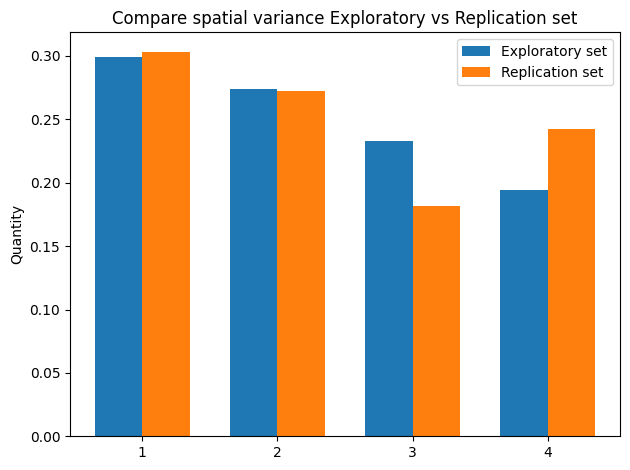

In [9]:
from collections import Counter
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import visualization as viz

c = Counter(df_new['PhenoGraph_clusters'])
l_new = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in replication set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))
c = Counter(df_cluster['PhenoGraph_clusters'])
l_old = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in original set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))

viz.plotSpatialVariation(l_new, l_old)

## Visualize joint involvement

In [10]:
import importlib as imp
import sys
sys.path.append(r'../../../src/1_emr_scripts')
import MannequinFunctions as func
imp.reload(func)

<module 'MannequinFunctions' from '../../../src/1_emr_scripts/MannequinFunctions.py'>

(-0.5, 1452.5, 1799.5, -0.5)

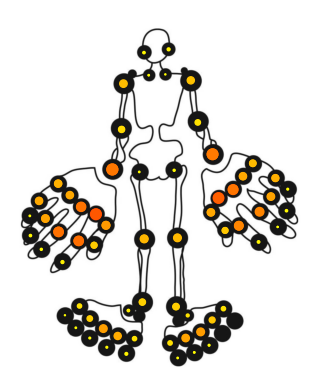

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

CLUSTER =2
CATEGORY = 'Zwelling' # 'Zwelling'
# Import mannequin information
df_man = pd.read_csv('Total/Metadata_complete_Nordstar.csv', sep='|') 
df_man = df_man[df_man['Replication']==1].copy()
df_man['PhenoGraph_clusters'] = df_new['PhenoGraph_clusters'].copy()
df_cluster['PATNR']=df_cluster['pseudoId'].copy()
l_pat = set(df_man[df_man['PhenoGraph_clusters']==CLUSTER]['PATNR'])
df_sub = df_man[df_man['PATNR'].isin(l_pat)].copy()

#create scatterplot (toDo: for both big & small joints)
#l_col = [col for col in df_sub.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'PATNR']]
l_mannequin = [col for col in metadata_RA.columns if ((('Zwelling_' in col or 'Pijn_' in col)) and 'positive' in col)]
l_col = [col for col in l_mannequin ] #if CATEGORY in col
df_plot = pd.DataFrame(df_sub[l_col].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
df_plot['s'] = df_plot['s'] * df_plot['value']

# Visualize gestalt
im = plt.imread('../../../figures/2_processing/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, vmin=0, vmax=1, cmap='autumn_r')
fig = plt.gcf()
fig.set_dpi(100)
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
plt.axis('off')

### #3.6 Visualize Learned embedding

In [ ]:
import sys
sys.path.append(r'../')
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import pandas as pd
import numpy as np

df_z = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Nordstar_embedding_projections.csv', sep=',')
l_embedding = [col for col in df_z.columns]

# Variables from replication set
df_projection = pd.read_csv('Total/ClusterAssignment_Nordstar.csv', sep=',')

# Select complete patients
#l_essential = ['SJC', 'Leuko', 'Hb', 'MCV', 'Trom',  'BSE', 'RF', 'aCCP', 'Age', 'Sex', 'PATNR']
#df_meta = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/offshoots/BeST/metadata_best.csv', sep='|')
#l_pat_repl = list(df_meta[l_essential].dropna()['PATNR'].unique())

# import metadata of SyG replication set
metadata_rep = pd.read_csv('Total/Metadata_complete_Nordstar.csv', sep='|')
metadata_rep = metadata_rep[metadata_rep['Replication']==1].copy()
metadata_rep = metadata_rep.reset_index(drop=True)

# add cluster info for projected patietns
metadata_rep['PhenoGraph_clusters'] = df_projection['PhenoGraph_clusters'].copy() # len(metadata['PhenoGraph_clusters'].unique())+1

# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0

# Combine both metadatas
metadata = metadata_RA.append(metadata_rep, ignore_index = True)

# Add projected patients to original set
l_latent = [col for col in l_embedding if col not in ['pseudoId', 'PATNR']]

print('BEFORE: total samples for tsne: ', len(metadata_RA))
metadata_total, z_total = pup.add_projected_patients(metadata_RA, pd.DataFrame(z_filtered, columns=l_latent), metadata_rep, z_patient[l_latent]) # ix = 
print('After: total samples for tsne: ', len(metadata_total))

In [ ]:
metadata_total.to_csv('Total/Nordstar_Complete_META.csv', sep=';', index=None)

In [ ]:
z_filtered[0]

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Define the encoder model
def create_encoder(input_dim, latent_dim):
    input_layer = Input(shape=(input_dim,))
    x = Dense(64, activation='sigmoid')(input_layer) # sigmoid
    x = Dense(32, activation='sigmoid')(x)
    x = Dense(16, activation='sigmoid')(x)
    latent_space = Dense(latent_dim)(x)  # No activation in the output layer

    return Model(input_layer, latent_space, name='encoder')
 
# Parameters
input_dim = 8
latent_dim = 2  # Target dimension for UMAP

encoder = create_encoder(input_dim, latent_dim)
encoder.summary()

In [ ]:
from umap.parametric_umap import ParametricUMAP
import importlib as imp

keras_fit_kwargs = {"callbacks": [
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        min_delta=10**-4,
        patience=10,
        verbose=1,
    )
]}

SEED = 20240506 # 
#SEED = 202405421 # 

embedder = ParametricUMAP(random_state=SEED, keras_fit_kwargs=keras_fit_kwargs, encoder=encoder, n_training_epochs=10) #
embedding = embedder.fit_transform(z_filtered)
pup.plot_tsne(embedding, group_id=metadata_RA['PhenoGraph_clusters'], path='Total/umap_original_Nordstar.png')

# save parametric UMAP
embedder.save('../../models/umap/umap_mapping_Nordstar')

In [ ]:
# Project replication data onto tSNE
fit2 = embedder.transform(z_total.values)

# Plot Umap as 2d image
pup.plot_tsne(fit2, group_id=metadata_total['Replication'], path='Total/umap_replication_projected_Nordstar.png')


### Create Cluster table 
use metadata_total

In [ ]:
import pandas as pd
metadata_total = pd.read_csv('Total/Nordstar_Complete_META.csv', sep=';')
metadata_total['PATNR'].unique()

In [ ]:
import pandas as pd
metadata_total = pd.read_csv('Total/Nordstar_Complete_META.csv', sep=';')
extra_meta = pd.read_csv('Leiden_20240401.csv', sep=';')

df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',
# Drop columns with only missing values
df_subset = df_subset.dropna(axis=1, how='all')
df_full = pd.merge(df_subset, extra_meta, left_on='PATNR', right_on='SubjectId')
df_full = df_full.drop_duplicates(subset='SubjectId', keep='first')

In [ ]:
import numpy as np

def IQR(data):
    # First quartile (Q1)
    Q1 = np.percentile(data, 25, interpolation = 'midpoint')

    # Third quartile (Q3)
    Q3 = np.percentile(data, 75, interpolation = 'midpoint')
   
    # Interquaritle range (IQR)
    iqr = Q3 - Q1
    return [Q1, Q3]

df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'ESR (median+-IQR)', 'DAS28 (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'RF_na [n(%)]','ACPA_na [n(%)]', 'ESR_na [n(%)]' , 'Mannequin_na [n(%)]']) #TreatSwitch [n(%)]', 

#df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',
#df_subset['symptomDuration'] = df_subset['symptomDuration']*7 # give symptom duration in days

def generate_baseline_ref(df_baseline, name = 'All', frac=''):
    if frac != '' :
        frac = '(' + frac + ')'
    return [name, '%.0f %s' % (len(df_baseline), frac), 
     '%.0f (%.1f)' % (np.sum(df_baseline['Sex']), np.mean(df_baseline['Sex']) * 100), 
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['Age'].isna()]['Age']), IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[0], IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[1]),
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['RF'].isna()]['RF']), np.mean(df_baseline[~df_baseline['RF'].isna()]['RF']) * 100), 
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']), np.mean(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']) * 100), 
       
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['BSE'].isna()]['BSE']), IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[0], IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28']), IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[0], IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['SJC'].isna()]['SJC']), IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[0], IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['TJC'].isna()]['TJC']), IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[0], IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[1]),
     
     #'%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration']), IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[0], IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[1]),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['RF'].isna()]), (len(df_baseline[df_baseline['RF'].isna()])/len(df_baseline))*100), '%.0f (%.1f)' % (len(df_baseline[df_baseline['aCCP'].isna()]), (len(df_baseline[df_baseline['aCCP'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['BSE'].isna()]), (len(df_baseline[df_baseline['BSE'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['SJC'].isna()]), (len(df_baseline[df_baseline['SJC'].isna()])/len(df_baseline))*100),
     
    ]  # finalCDAI
#df_summary.loc[0] = generate_baseline_ref(df_full, 'All')

for i in range(len(df_full['PhenoGraph_clusters'].unique())):
    df_summary.loc[i] = generate_baseline_ref(df_full[df_full['PhenoGraph_clusters']==i], 'Cluster %s' % str(i+1))

df_summary = df_summary.reset_index(drop=True)
df_summary.T

In [ ]:
df_full['Cluster'] = df_full['PhenoGraph_clusters'].copy() + 1

l_metadata = ['PATNR', 'CountryId', 'Cluster', 'Sex', 'Age', 'RF', 'aCCP', 'SJC', 'TJC', 'BSE', 'CALC_DAS28']
df_full[l_metadata].to_csv('Total/df_clusters_nordstar.csv', sep='|', index=False)#[l_cat]

In [359]:
df_summary.loc[0] = generate_baseline_ref(df_full, 'All')
df_summary.T[[0]]

,0
cluster,All
N,804
"Sex, F [n(%)]",556 (69.2)
Age (median+-IQR),56.0 (46.0-66.0)
RF [n(%)],602.0 (74.9)
ACPA [n(%)],659.0 (82.0)
ESR (median+-IQR),27.0 (15.0-43.0)
DAS28 (median+-IQR),4.9 (4.2-5.7)
SJC (median+-IQR),9.0 (6.0-14.0)
TJC (median+-IQR),13.0 (8.0-19.5)


### create UMAP showing reclustered patients

In [ ]:
import pandas as pd

metadata_total = pd.read_csv('Total/Nordstar_Complete_META.csv', sep=';')
extra_meta = pd.read_csv('Leiden_20240401.csv', sep=';')

df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',
# Drop columns with only missing values
df_subset = df_subset.dropna(axis=1, how='all')
df_full = pd.merge(df_subset, extra_meta, left_on='PATNR', right_on='SubjectId')
df_full = df_full.drop_duplicates(subset='SubjectId', keep='first')
# Save embedding + projection
df_z = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Nordstar_embedding_projections.csv', sep=',')
df_z

In [361]:
l_embedding = list(df_z.columns)[1:]
metadata_total = metadata_total.merge(df_z, how='inner', left_index=True, right_index=True)
df_categoric_replication = pd.read_csv('Total/df_Nordstar_categoric_ohe.csv', sep='|')#[l_cat]
l_cat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]

### Add country ids

In [362]:
import numpy as np

# Convert categorical column to dummy variables
df_countries = pd.get_dummies(df_full, columns=['CountryId'])
df_new = pd.concat([df_full[['SubjectId']], df_countries])

# 
for i in df_full['CountryId'].unique():
    d_country = dict(zip(df_new['SubjectId'].astype(str), df_new['CountryId_%s' % i ])) 
    metadata_total['CountryId_%s' % i] = metadata_total['PATNR_y'].apply(lambda x : d_country[x] if x in d_country.keys() else np.nan) 

l_cat_spec = ['RF']
l_cat_spec.extend([col for col in metadata_total.columns if col not in ['RF']]) 
#l_cat_spec.append('PATNR_y')

In [363]:
from umap.parametric_umap import load_ParametricUMAP
import sys
sys.path.append(r'../src/')
import Visualization as func
embedder = load_ParametricUMAP('../umap/umap_mapping_Nordstar')

# Project replication data onto tSNE
X_embedded = embedder.transform(metadata_total[l_embedding])
#l_cat.append('PATNR_y')

func.visualize_umap_bokeh_na_2(X_embedded, metadata_total[l_cat_spec],  l_cat_spec, l_binary=l_cat, patient_id='PATNR_y', cluster_id='PhenoGraph_clusters', title='MMAE_UMAP2',  path='Total/NORDSTAR_MMAE_clustered.html')

Pickle of ParametricUMAP model loaded from ../../models/umap/umap_mapping_Nordstar/model.pkl
Keras encoder model loaded from ../../models/umap/umap_mapping_Nordstar/encoder
Keras full model loaded from ../../models/umap/umap_mapping_Nordstar/parametric_model
2191 2191
0 []

UMAP figure saved under location: TSNE/Baseline_MMAE_UMAP2.html


In [364]:
func.visualize_umap_bokeh_na_2(X_embedded, metadata_total[l_cat_spec],  l_cat_spec, l_binary=l_cat, patient_id='PATNR_y', cluster_id='PhenoGraph_clusters', title='MMAE_UMAP2',  path='Total/NORDSTAR_MMAE_clustered.html')

2191 2191
0 []

UMAP figure saved under location: TSNE/Baseline_MMAE_UMAP2.html


In [365]:
final_cdai = {}
for pat in extra_meta['SubjectId'].unique():
    df_cdai = extra_meta[extra_meta['SubjectId']==pat]['CALC_CDAI'].dropna()
    try:
        final_cdai[pat] = df_cdai.iloc[-1]
    except: 
        final_cdai[pat] = np.nan
        
df_full['finalCDAI'] = df_full['PATNR'].apply(lambda x : final_cdai[x])

In [367]:
import numpy as np

def IQR(data):
    # First quartile (Q1)
    Q1 = np.percentile(data, 25, interpolation = 'midpoint')

    # Third quartile (Q3)
    Q3 = np.percentile(data, 75, interpolation = 'midpoint')
   
    # Interquaritle range (IQR)
    iqr = Q3 - Q1
    return [Q1, Q3]

df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'ESR (median+-IQR)', 'DAS28 (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'finalCDAI (median+-IQR)','RF_na [n(%)]','ACPA_na [n(%)]', 'ESR_na [n(%)]' , 'Mannequin_na [n(%)]']) #TreatSwitch [n(%)]', 

#df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',
#df_subset['symptomDuration'] = df_subset['symptomDuration']*7 # give symptom duration in days

def generate_baseline_ref(df_baseline, name = 'All', frac=''):
    if frac != '' :
        frac = '(' + frac + ')'
    return [name, '%.0f %s' % (len(df_baseline), frac), 
     '%.0f (%.1f)' % (np.sum(df_baseline['Sex']), np.mean(df_baseline['Sex']) * 100), 
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['Age'].isna()]['Age']), IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[0], IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[1]),
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['RF'].isna()]['RF']), np.mean(df_baseline[~df_baseline['RF'].isna()]['RF']) * 100), 
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']), np.mean(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']) * 100), 
       
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['BSE'].isna()]['BSE']), IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[0], IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28']), IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[0], IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['SJC'].isna()]['SJC']), IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[0], IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['TJC'].isna()]['TJC']), IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[0], IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[1]),
     
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['finalCDAI'].isna()]['finalCDAI']), IQR(df_baseline[~df_baseline['finalCDAI'].isna()]['finalCDAI'])[0], IQR(df_baseline[~df_baseline['finalCDAI'].isna()]['finalCDAI'])[1]),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['RF'].isna()]), (len(df_baseline[df_baseline['RF'].isna()])/len(df_baseline))*100), '%.0f (%.1f)' % (len(df_baseline[df_baseline['aCCP'].isna()]), (len(df_baseline[df_baseline['aCCP'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['BSE'].isna()]), (len(df_baseline[df_baseline['BSE'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['SJC'].isna()]), (len(df_baseline[df_baseline['SJC'].isna()])/len(df_baseline))*100),
     
    ]  # finalCDAI
#df_summary.loc[0] = generate_baseline_ref(df_full, 'All')

for i in range(len(df_full['PhenoGraph_clusters'].unique())):
    df_summary.loc[i] = generate_baseline_ref(df_full[df_full['PhenoGraph_clusters']==i], 'Cluster %s' % str(i+1))

df_summary = df_summary.reset_index(drop=True)
df_summary.T

,0,1,2,3
cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4
N,244,219,146,195
"Sex, F [n(%)]",176 (72.1),157 (71.7),91 (62.3),132 (67.7)
Age (median+-IQR),49.0 (41.0-62.0),57.0 (49.0-65.0),62.0 (55.0-69.5),55.0 (41.0-66.0)
RF [n(%)],191.0 (78.3),174.0 (79.5),103.0 (70.5),134.0 (68.7)
ACPA [n(%)],212.0 (86.9),198.0 (90.4),105.0 (71.9),144.0 (73.8)
ESR (median+-IQR),21.0 (11.0-33.0),27.0 (14.0-47.0),31.0 (19.0-47.0),31.0 (18.5-53.0)
DAS28 (median+-IQR),4.8 (4.1-5.4),4.4 (3.7-5.1),5.2 (4.6-5.8),5.6 (4.9-6.4)
SJC (median+-IQR),9.0 (6.0-13.0),6.0 (4.0-8.0),10.0 (7.0-14.0),16.0 (10.0-22.0)
TJC (median+-IQR),13.5 (8.0-19.0),8.0 (5.0-12.0),13.0 (10.0-18.0),22.0 (14.0-31.0)


### Check which patients are dropped due to incomplete data!

In [ ]:
#df_extra_meta[df_extra_meta['PATNR'].isin(l_pat_dropped)]['CountryId']
set(df_extra_meta['PATNR'].unique()) - set(df_numeric_replication['PATNR'].unique())

<AxesSubplot:>

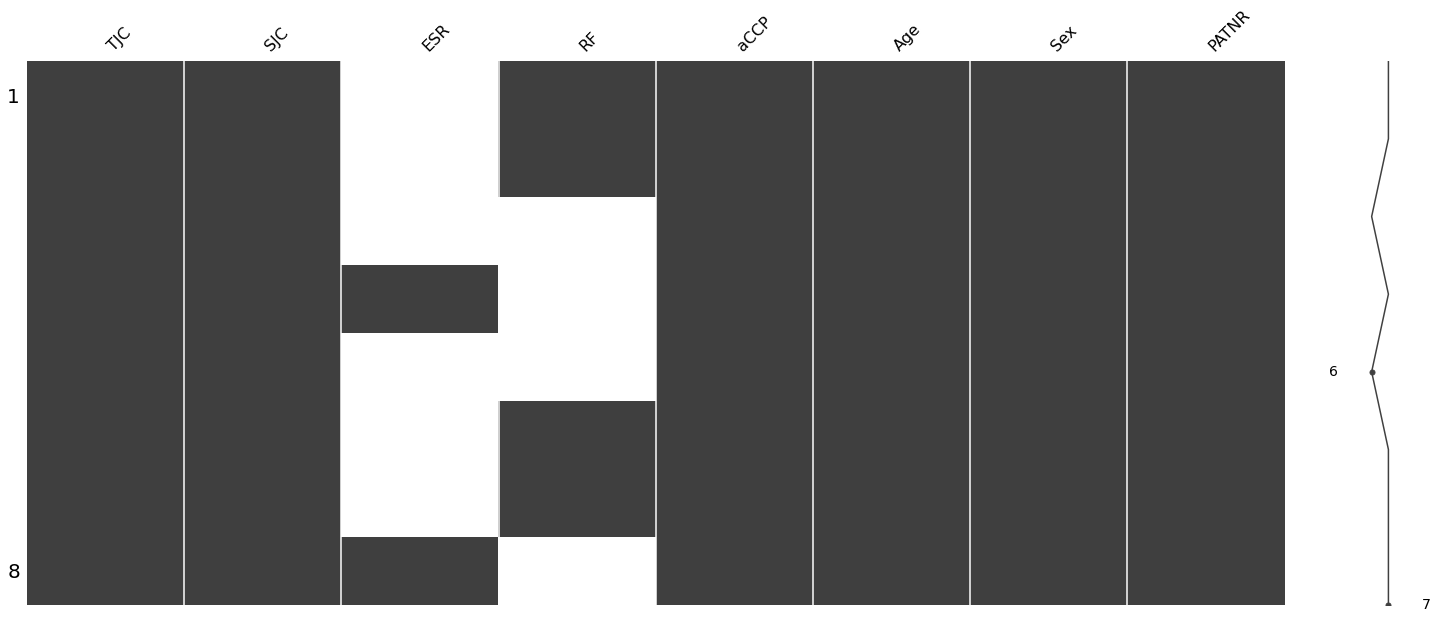

In [40]:
import pandas as pd
import missingno as msno
df_extra_meta = pd.read_csv('Leiden_20240401.csv', sep=';')
l_essential_test = ['TJC', 'SJC', 'ESR','RF', 'aCCP', 'Age', 'Sex', 'PATNR'] # no 'Ht',  #'CRP',  
df_extra_meta = df_extra_meta.rename(columns= {'SubjectId' : 'PATNR', 'CALC_AGE' : 'Age', 'PATSEXCD' : 'Sex', 'CALC_BMI' : 'BMI', 'ANSRVAL' : 'ESR',
 'ANCRPVAL' : 'CRP', 'ANCCPRESCD' : 'aCCP', 'ANRFRESCD' : 'RF'})
df_extra_meta = df_extra_meta[df_extra_meta['EventId']=='00_SCR']

l_pat_dropped = set(df_extra_meta['PATNR'].unique()) - set(df_meta_new['PATNR'].unique())
    
%matplotlib inline
msno.matrix(df_extra_meta[df_extra_meta['PATNR'].isin(l_pat_dropped)][l_essential_test]) # check if patients that miss variables across lines -> have aCCP / RF of 2df_lab_sc